
# Single-qubit AoT and AoT susceptibility

This notebook is a controlled one-qubit test of the direct tangent-state susceptibility method.

The important correction relative to the previous version is that the derivative of the **full** AoT,

$$
Q(g)=\gamma \Delta t\sum_\tau \left(1+z_\tau^2\right),
$$

contains a trivial explicit prefactor contribution:

$$
\frac{dQ}{d\ln g}=Q+\gamma\Delta t\sum_\tau 2 z_\tau u_\tau.
$$

Therefore $Q$ and $dQ/d\ln g$ can look very similar. To isolate the state-response part, we also compute the normalized AoT density

$$
q(g)=\frac{1}{N_{\rm eff}}\sum_{\tau\in {\rm measured}}\left(1+z_\tau^2\right),
$$

and its susceptibility

$$
\chi_q(g)=\frac{dq}{d\ln g}=\frac{1}{N_{\rm eff}}\sum_{\tau\in {\rm measured}}2z_\tau u_\tau.
$$

Here

$$
u_\tau=u_\tau=\partial_{\ln g}z_\tau,
\qquad
z_\tau=\langle\psi_\tau|\sigma_z|\psi_\tau\rangle.
$$

The simulation evolves both the physical state $|\psi\rangle$ and the tangent state

$$
|\eta\rangle=\partial_{\ln g}|\psi\rangle.
$$

For this notebook we use the ordinary one-qubit state vector, not the correlation-matrix method. The Hamiltonian time evolution is performed using an exact eigensolver construction of $U=\exp(-iH\Delta t)$.



## 1. Imports and Pauli matrices

The Hamiltonian used below is

$$
H=J\sigma_y.
$$

The measurement is a weak stochastic measurement of $\sigma_z$.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

GLOBAL_SEED = 1234

I2 = np.eye(2, dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "font.size": 12,
})



## 2. Exact unitary evolution from an eigensolver

For one qubit, the exact unitary can be built by diagonalizing the Hamiltonian:

$$
H=V\Lambda V^\dagger,
\qquad
U=V e^{-i\Lambda\Delta t} V^\dagger.
$$

Since $H$ is independent of $g$, the tangent state evolves under the same unitary:

$$
|\psi\rangle\mapsto U|\psi\rangle,
\qquad
|\eta\rangle\mapsto U|\eta\rangle.
$$


In [ ]:

def exact_unitary_from_eigensolver(H, dt):
    # Return exp(-i H dt) using Hermitian diagonalization.
    evals, evecs = np.linalg.eigh(H)
    phases = np.exp(-1j * evals * dt)
    return evecs @ np.diag(phases) @ evecs.conj().T


def normalize_with_tangent(v, w):
    # If psi_new = v / ||v|| and w = d v / d theta, then
    # eta_new = (w - psi_new Re<psi_new|w>) / ||v||.
    # This is not a normalization of eta to unit norm. It is the derivative of
    # the normalization applied to the physical state.
    nrm = np.linalg.norm(v)
    psi_new = v / nrm
    proj = np.real(np.vdot(psi_new, w))
    eta_new = (w - psi_new * proj) / nrm
    return psi_new, eta_new


def unitary_step(psi, eta, U):
    return U @ psi, U @ eta



## 3. Measurement update and tangent update

We use the weak-measurement update

$$
|\psi'\rangle_{\rm raw}=\left[I+\xi\epsilon A-\frac{1}{2}\epsilon^2 A^2\right]|\psi\rangle,
$$

where

$$
A=\frac{\sigma_z-zI}{2},
\qquad
z=\langle\psi|\sigma_z|\psi\rangle,
\qquad
\epsilon^2=\gamma\Delta t.
$$

The tangent variable is

$$
|\eta\rangle=\partial_{\ln g}|\psi\rangle.
$$

The scalar response is

$$
u=u=\partial_{\ln g}z=2\operatorname{Re}\langle\eta|\sigma_z|\psi\rangle.
$$

Since $A=(\sigma_z-zI)/2$,

$$
A_\theta=-\frac{u}{2}I.
$$

Also,

$$
\partial_{\ln g}\epsilon=\frac{1}{2}\epsilon,
\qquad
\partial_{\ln g}\epsilon^2=\epsilon^2.
$$

The raw tangent update is obtained by differentiating the raw measurement operator. Then, because this numerical implementation explicitly normalizes the raw state, we differentiate that normalization as well.


In [ ]:

def measurement_step_article(psi, eta, gamma, dt, rng):
    # One weak-measurement step plus tangent update.
    # Uses the article-style coefficient -1/2 epsilon^2 A^2.
    eps = np.sqrt(gamma * dt)
    xi = rng.choice([-1.0, 1.0])

    z = np.real(np.vdot(psi, sigma_z @ psi))
    u = 2.0 * np.real(np.vdot(eta, sigma_z @ psi))

    A = 0.5 * (sigma_z - z * I2)
    A_theta = -0.5 * u * I2

    M = I2 + xi * eps * A - 0.5 * (eps**2) * (A @ A)

    M_theta = (
        xi * 0.5 * eps * A
        + xi * eps * A_theta
        - 0.5 * (eps**2) * (A @ A)
        - 0.5 * (eps**2) * (A @ A_theta + A_theta @ A)
    )

    v = M @ psi
    w = M @ eta + M_theta @ psi

    psi_new, eta_new = normalize_with_tangent(v, w)
    return psi_new, eta_new, z, u, xi



## 4. Single-trajectory simulation

The function below simulates one trajectory and records both

$$
z(t)=\langle\sigma_z\rangle
$$

and

$$
u(t)=\partial_{\ln g}z(t).
$$

The initial state is fixed and independent of $g$, so

$$
|\eta_0\rangle=0.
$$


In [ ]:

def simulate_trajectory(gamma, J=1.0, dt=0.005, n_steps=4000, seed=0, psi0=None):
    rng = np.random.default_rng(seed)
    H = J * sigma_y
    U = exact_unitary_from_eigensolver(H, dt)

    if psi0 is None:
        psi = np.array([1.0, 1.0], dtype=complex) / np.sqrt(2.0)
    else:
        psi = np.array(psi0, dtype=complex)
        psi = psi / np.linalg.norm(psi)

    eta = np.zeros_like(psi)

    z_vals = np.empty(n_steps)
    u_vals = np.empty(n_steps)
    norm_err = np.empty(n_steps)
    gauge_err = np.empty(n_steps)

    for tau in range(n_steps):
        psi, eta, z, u, xi = measurement_step_article(psi, eta, gamma, dt, rng)
        psi, eta = unitary_step(psi, eta, U)

        # Optional tangent-plane projection to reduce numerical roundoff drift.
        eta = eta - psi * np.real(np.vdot(psi, eta))

        z_vals[tau] = z
        u_vals[tau] = u
        norm_err[tau] = abs(np.vdot(psi, psi).real - 1.0)
        gauge_err[tau] = abs(np.real(np.vdot(psi, eta)))

    return {
        "t": dt * np.arange(n_steps),
        "z": z_vals,
        "u": u_vals,
        "norm_err": norm_err,
        "gauge_err": gauge_err,
    }



## 5. Plot $z(t)$ and $u(t)$ for one value of $\gamma$

This is the basic sanity check. The two time series should look like physically reasonable stochastic trajectories.


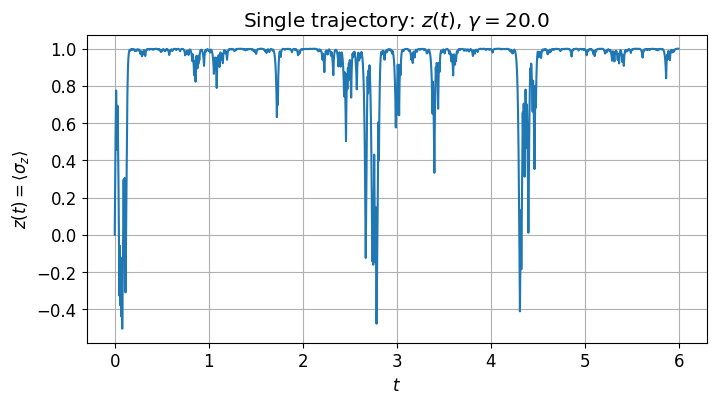

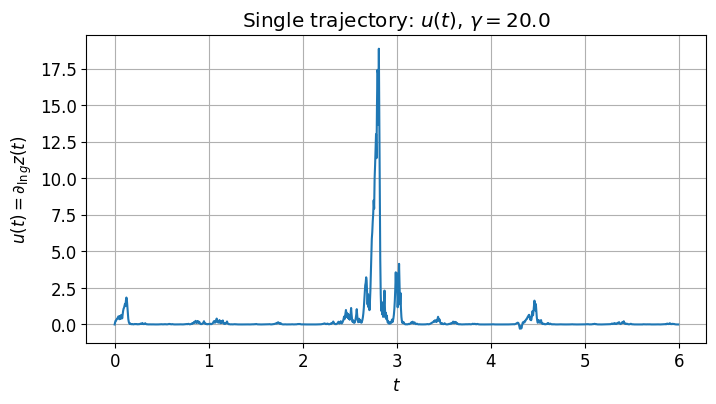

max norm error: 9.992007221626409e-16
max tangent-plane gauge error: 8.881784197001341e-16


In [ ]:

J = 1.0
dt = 0.005
n_steps = 4000
gamma_example = 20.0

traj = simulate_trajectory(gamma_example, J=J, dt=dt, n_steps=n_steps, seed=GLOBAL_SEED)

#
window = 1200

plt.figure()
plt.plot(traj["t"][:window], traj["z"][:window])
plt.xlabel(r"$t$")
plt.ylabel(r"$z(t)=\langle\sigma_z\rangle$")
plt.title(rf"Single trajectory: $z(t)$, $\gamma={gamma_example}$")
plt.show()

plt.figure()
plt.plot(traj["t"][:window], traj["u"][:window])
plt.xlabel(r"$t$")
plt.ylabel(r"$u(t)=\partial_{{\ln g}}z(t)$")
plt.title(rf"Single trajectory: $u(t)$, $\gamma={gamma_example}$")
plt.show()

print("max norm error:", np.max(traj["norm_err"]))
print("max tangent-plane gauge error:", np.max(traj["gauge_err"]))



## 6. AoT density and susceptibility estimators

For one trajectory after burn-in, define

$$
q=\langle 1+z^2\rangle_t,
\qquad
\chi_q=\langle 2zu\rangle_t.
$$

The full extensive quantities over the sampled time window are

$$
Q=\gamma\Delta t\sum_\tau(1+z_\tau^2),
$$

and

$$
\chi_Q=\frac{dQ}{d\ln g}=Q+\gamma\Delta t\sum_\tau 2z_\tau u_\tau.
$$

The full $Q$ and $\chi_Q$ may look similar because $\chi_Q$ explicitly contains $Q$. The more informative response diagnostic is $\chi_q$.


In [ ]:

def trajectory_observables(z, u, gamma, dt, burn_in=500):
    z_s = z[burn_in:]
    u_s = u[burn_in:]

    q_density = np.mean(1.0 + z_s**2)
    chi_density = np.mean(2.0 * z_s * u_s)

    Q_full = gamma * dt * np.sum(1.0 + z_s**2)
    chi_full = gamma * dt * np.sum(1.0 + z_s**2 + 2.0 * z_s * u_s)

    return q_density, chi_density, Q_full, chi_full


def ensemble_observables(g, J=1.0, dt=0.005, n_steps=4000, burn_in=800, n_traj=80, base_seed=0):
    gamma = 4.0 * J * g
    q_vals = []
    chi_q_vals = []
    Q_vals = []
    chi_Q_vals = []

    for r in range(n_traj):
        seed = base_seed + 100000 * r + int(1000 * g)
        tr = simulate_trajectory(gamma, J=J, dt=dt, n_steps=n_steps, seed=seed)
        q, chi_q, Q, chi_Q = trajectory_observables(tr["z"], tr["u"], gamma, dt, burn_in=burn_in)
        q_vals.append(q)
        chi_q_vals.append(chi_q)
        Q_vals.append(Q)
        chi_Q_vals.append(chi_Q)

    return {
        "g": g,
        "ln_g": np.log(g),
        "gamma": gamma,
        "q": float(np.mean(q_vals)),
        "chi_q": float(np.mean(chi_q_vals)),
        "Q": float(np.mean(Q_vals)),
        "chi_Q": float(np.mean(chi_Q_vals)),
        "q_err": float(np.std(q_vals, ddof=1) / np.sqrt(n_traj)) if n_traj > 1 else 0.0,
        "chi_q_err": float(np.std(chi_q_vals, ddof=1) / np.sqrt(n_traj)) if n_traj > 1 else 0.0,
    }



## 7. Run the scan over $g$

The range below is chosen so that $\gamma\Delta t$ remains moderately small. If you increase the largest $g$, decrease `dt` accordingly.

For a quick test, reduce `n_traj` or `n_steps`. For smoother plots, increase them.


In [ ]:

J = 1.0
dt = 0.005
n_steps = 20000
burn_in = 800
n_traj = 160

g_values = np.logspace(np.log10(0.1), np.log10(4.0), 35)

results = []
for idx, g in enumerate(g_values):
    print(f"running {idx+1}/{len(g_values)}: g={g:.4f}, gamma={4*J*g:.4f}")
    res = ensemble_observables(
        g,
        J=J,
        dt=dt,
        n_steps=n_steps,
        burn_in=burn_in,
        n_traj=n_traj,
        base_seed=GLOBAL_SEED,
    )
    results.append(res)

ln_g = np.array([r["ln_g"] for r in results])
q_vals = np.array([r["q"] for r in results])
chi_q_vals = np.array([r["chi_q"] for r in results])
Q_vals = np.array([r["Q"] for r in results])
chi_Q_vals = np.array([r["chi_Q"] for r in results])
q_err = np.array([r["q_err"] for r in results])
chi_q_err = np.array([r["chi_q_err"] for r in results])


running 1/35: g=0.1000, gamma=0.4000
running 2/35: g=0.1115, gamma=0.4458
running 3/35: g=0.1242, gamma=0.4969
running 4/35: g=0.1385, gamma=0.5539
running 5/35: g=0.1543, gamma=0.6174
running 6/35: g=0.1720, gamma=0.6881
running 7/35: g=0.1917, gamma=0.7670
running 8/35: g=0.2137, gamma=0.8549
running 9/35: g=0.2382, gamma=0.9528
running 10/35: g=0.2655, gamma=1.0620
running 11/35: g=0.2959, gamma=1.1837
running 12/35: g=0.3298, gamma=1.3194
running 13/35: g=0.3676, gamma=1.4706
running 14/35: g=0.4098, gamma=1.6391
running 15/35: g=0.4567, gamma=1.8270
running 16/35: g=0.5091, gamma=2.0363
running 17/35: g=0.5674, gamma=2.2697
running 18/35: g=0.6325, gamma=2.5298
running 19/35: g=0.7049, gamma=2.8197
running 20/35: g=0.7857, gamma=3.1429
running 21/35: g=0.8758, gamma=3.5031
running 22/35: g=0.9761, gamma=3.9045
running 23/35: g=1.0880, gamma=4.3520
running 24/35: g=1.2127, gamma=4.8507
running 25/35: g=1.3517, gamma=5.4066
running 26/35: g=1.5066, gamma=6.0262
running 27/35: g=1.67


## 8. Plot the normalized AoT density $q(\ln g)$

This is usually the better one-qubit diagnostic than the full extensive $Q$.


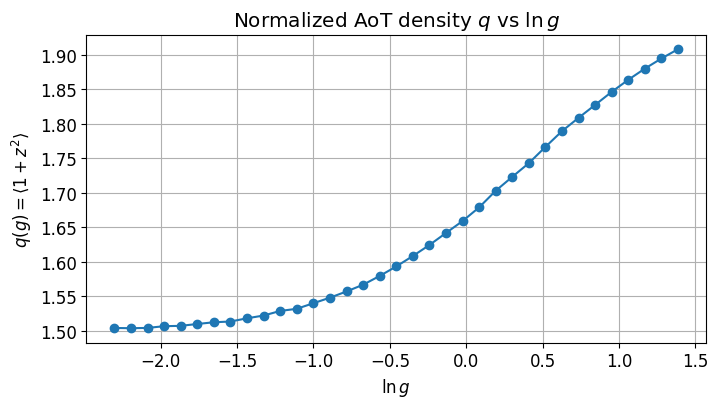

In [ ]:

plt.figure()
plt.errorbar(ln_g, q_vals, yerr=q_err, marker="o", capsize=3)
plt.xlabel(r"$\ln g$")
plt.ylabel(r"$q(g)=\langle 1+z^2\rangle$")
plt.title(r"Normalized AoT density $q$ vs $\ln g$")
plt.show()



## 9. Plot the density susceptibility $\chi_q(\ln g)$

This isolates the state response:

$$
\chi_q=\frac{dq}{d\ln g}=\langle 2zu\rangle.
$$


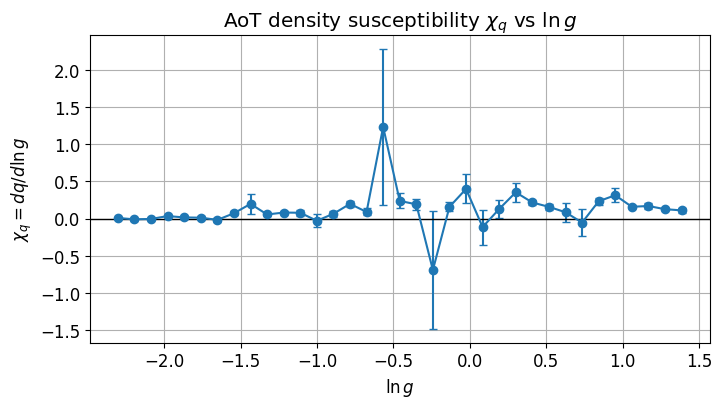

In [ ]:

plt.figure()
plt.errorbar(ln_g, chi_q_vals, yerr=chi_q_err, marker="o", capsize=3)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel(r"$\ln g$")
plt.ylabel(r"$\chi_q=dq/d\ln g$")
plt.title(r"AoT density susceptibility $\chi_q$ vs $\ln g$")
plt.show()



## 10. Optional: full extensive $Q$ and $dQ/d\ln g$

These are included for comparison. They can look similar because

$$
\frac{dQ}{d\ln g}=Q+\gamma\Delta t\sum_\tau 2z_\tau u_\tau.
$$


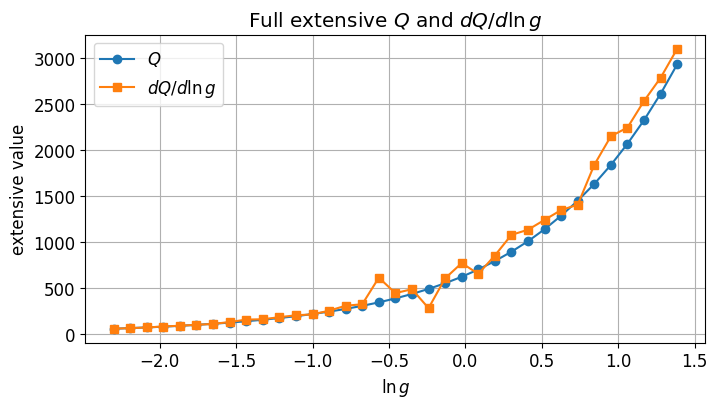

In [ ]:

plt.figure()
plt.plot(ln_g, Q_vals, marker="o", label=r"$Q$")
plt.plot(ln_g, chi_Q_vals, marker="s", label=r"$dQ/d\ln g$")
plt.xlabel(r"$\ln g$")
plt.ylabel("extensive value")
plt.title(r"Full extensive $Q$ and $dQ/d\ln g$")
plt.legend()
plt.show()



## 11. Optional finite-difference diagnostic

This cell is not meant to be the production method. It is only a sanity check. It compares the tangent estimator for $\chi_q$ with a finite-difference derivative of the ensemble-averaged $q$ curve.

Because finite differences of stochastic observables can be noisy, the comparison is qualitative unless many trajectories are used.


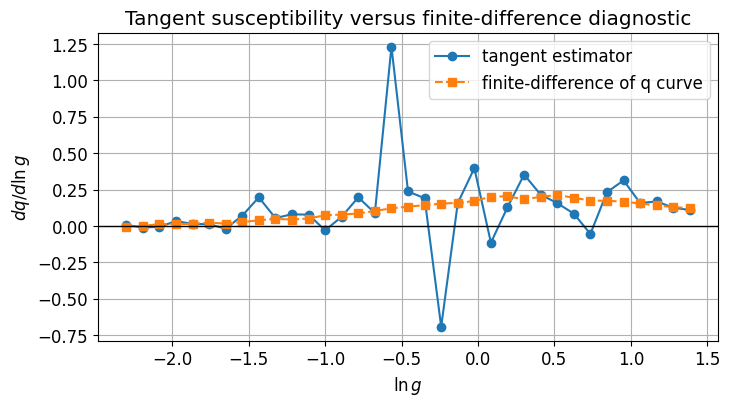

In [ ]:

chi_q_fd = np.gradient(q_vals, ln_g)

plt.figure()
plt.plot(ln_g, chi_q_vals, marker="o", label="tangent estimator")
plt.plot(ln_g, chi_q_fd, marker="s", linestyle="--", label="finite-difference of q curve")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel(r"$\ln g$")
plt.ylabel(r"$dq/d\ln g$")
plt.title("Tangent susceptibility versus finite-difference diagnostic")
plt.legend()
plt.show()
